# Phase 3: Capacity Planning & Predictive Analytics
In this phase, we analyze capacity trends, build forecasting models with Prophet, and score risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from prophet import Prophet
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
os.makedirs('../reports/charts', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

Importing plotly failed. Interactive plots will not work.


## Task 1 — Exploratory Capacity Analysis

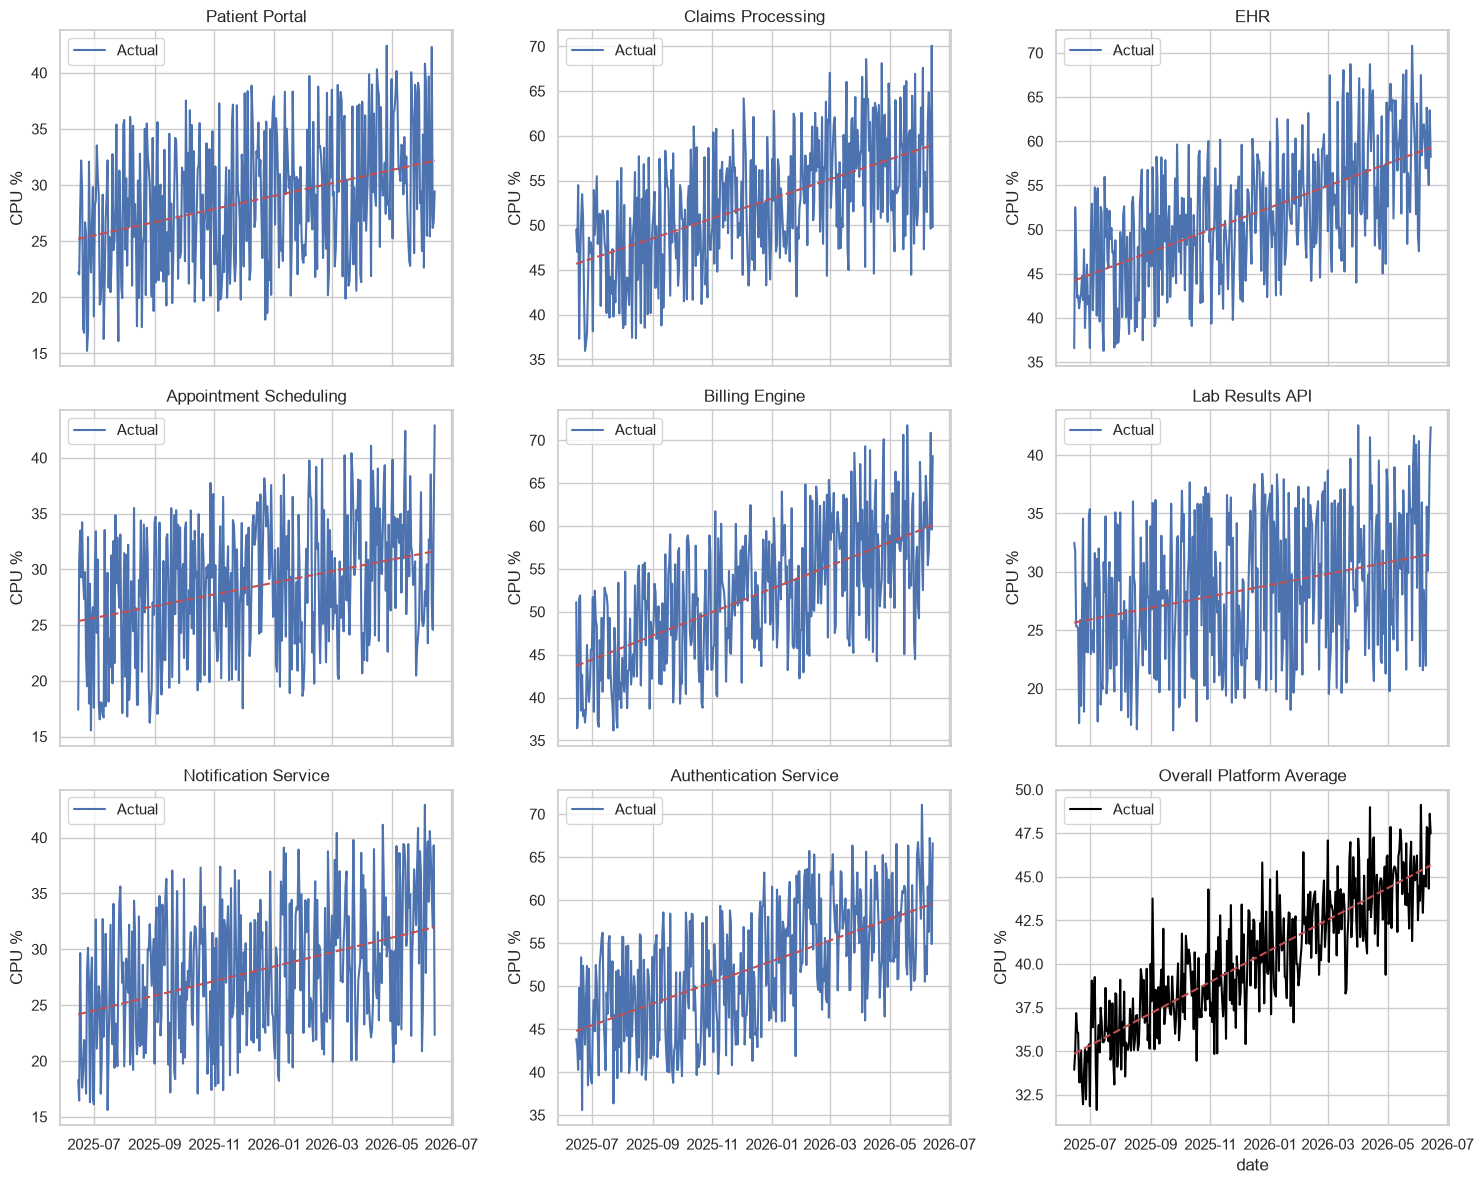

In [2]:
# Load data
df_capacity = pd.read_csv('../data/raw/capacity.csv')
df_services = pd.read_csv('../data/raw/services.csv')
df_merged = pd.merge(df_capacity, df_services, on='service_id', how='left')
df_merged['date'] = pd.to_datetime(df_merged['date'])

# 3x3 Grid of CPU Utilization Trends
services = df_merged['service_name'].unique()
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, svc in enumerate(services):
    svc_data = df_merged[df_merged['service_name'] == svc].sort_values('date')
    x = np.arange(len(svc_data))
    y = svc_data['cpu_utilization_pct'].values
    
    sns.lineplot(data=svc_data, x='date', y='cpu_utilization_pct', ax=axes[i], label='Actual')
    
    slope, intercept, r, p, se = linregress(x, y)
    axes[i].plot(svc_data['date'], intercept + slope*x, 'r--', label='Trend')
    
    axes[i].set_title(svc)
    axes[i].set_ylabel('CPU %')
    axes[i].set_xlabel('')

# 9th plot for overall
overall_data = df_merged.groupby('date')['cpu_utilization_pct'].mean().reset_index()
x_ov = np.arange(len(overall_data))
y_ov = overall_data['cpu_utilization_pct'].values
sns.lineplot(data=overall_data, x='date', y='cpu_utilization_pct', ax=axes[8], color='black', label='Actual')
slope_ov, intercept_ov, _, _, _ = linregress(x_ov, y_ov)
axes[8].plot(overall_data['date'], intercept_ov + slope_ov*x_ov, 'r--', label='Trend')
axes[8].set_title('Overall Platform Average')
axes[8].set_ylabel('CPU %')

plt.tight_layout()
plt.savefig('../reports/charts/cpu_trend_grid.png')
plt.show()

Top 3 Services with Steepest CPU Upward Trend:
             service_name  cpu_trend_slope
4          Billing Engine         0.045033
2                     EHR         0.041384
7  Authentication Service         0.040648


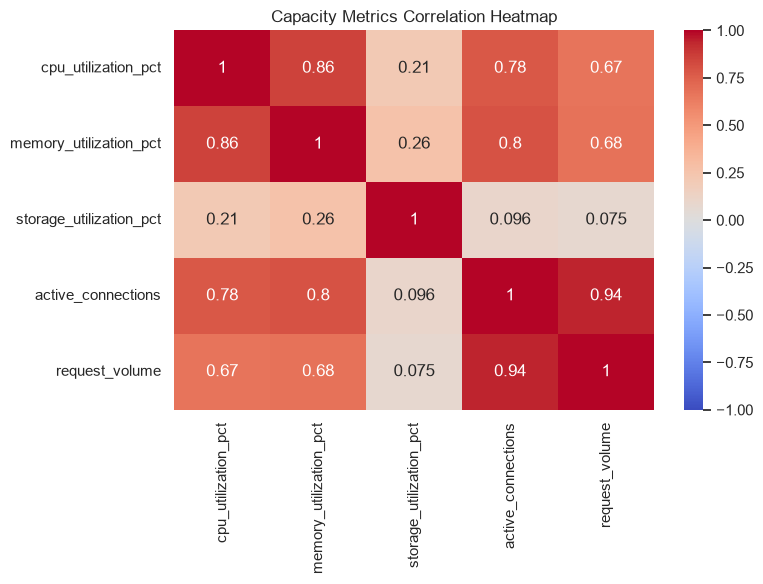

In [3]:
# Month-over-month growth rate and Top 3 steepest trends
df_merged['month'] = df_merged['date'].dt.to_period('M')
monthly_avg = df_merged.groupby(['service_name', 'month'])[['cpu_utilization_pct', 'memory_utilization_pct', 'storage_utilization_pct']].mean().reset_index()

slopes = []
for svc in services:
    svc_data = df_merged[df_merged['service_name'] == svc].sort_values('date')
    x = np.arange(len(svc_data))
    slope_cpu, _, _, _, _ = linregress(x, svc_data['cpu_utilization_pct'])
    slopes.append({'service_name': svc, 'cpu_trend_slope': slope_cpu})
    
slopes_df = pd.DataFrame(slopes).sort_values('cpu_trend_slope', ascending=False)
print("Top 3 Services with Steepest CPU Upward Trend:")
print(slopes_df.head(3))

# Correlation Heatmap
corr_cols = ['cpu_utilization_pct', 'memory_utilization_pct', 'storage_utilization_pct', 'active_connections', 'request_volume']
corr_matrix = df_merged[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Capacity Metrics Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/charts/capacity_correlation.png')
plt.show()

## Task 2 — Time Series Forecasting with Facebook Prophet

In [4]:
def forecast_metric(df, metric_name, horizon=90):
    forecast_results = []
    all_forecasts_df = pd.DataFrame()
    
    for svc in services:
        # Prepare data for Prophet
        svc_data = df[df['service_name'] == svc][['date', metric_name]]
        svc_data.columns = ['ds', 'y']
        
        model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model.fit(svc_data)
        
        future = model.make_future_dataframe(periods=horizon)
        forecast = model.predict(future)
        
        # Plot
        fig = model.plot(forecast)
        plt.title(f'{svc} - {metric_name} Forecast')
        plt.ylabel(f'{metric_name} %')
        plt.xlabel('Date')
        plt.savefig(f'../reports/charts/forecast_{svc.replace(" ", "_")}_{metric_name}.png')
        plt.close(fig)
        
        # Extract specific days
        current_avg = svc_data['y'].tail(30).mean()
        last_date = svc_data['ds'].max()
        
        f_30 = forecast[forecast['ds'] == last_date + pd.Timedelta(days=30)]['yhat'].values[0]
        f_60 = forecast[forecast['ds'] == last_date + pd.Timedelta(days=60)]['yhat'].values[0]
        f_90 = forecast[forecast['ds'] == last_date + pd.Timedelta(days=90)]['yhat'].values[0]
        
        forecast_results.append({
            'service_name': svc,
            f'current_{metric_name}_avg': current_avg,
            'forecast_30d': f_30,
            'forecast_60d': f_60,
            'forecast_90d': f_90
        })
        
        # Save full forecast for Power BI
        f_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon).copy()
        f_df['service_name'] = svc
        f_df['metric'] = metric_name.replace('_utilization_pct', '')
        f_df.rename(columns={'ds': 'date', 'yhat': 'forecasted_value', 'yhat_lower': 'lower_bound', 'yhat_upper': 'upper_bound'}, inplace=True)
        all_forecasts_df = pd.concat([all_forecasts_df, f_df])
        
    summary_df = pd.DataFrame(forecast_results)
    summary_df.to_csv(f'../reports/capacity_forecast_summary_{metric_name}.csv', index=False)
    return summary_df, all_forecasts_df

print("Forecasting CPU...")
cpu_summary, cpu_full = forecast_metric(df_merged, 'cpu_utilization_pct')

print("Forecasting Memory...")
mem_summary, mem_full = forecast_metric(df_merged, 'memory_utilization_pct')

print("Forecasting Storage...")
storage_summary, storage_full = forecast_metric(df_merged, 'storage_utilization_pct')


Forecasting CPU...


19:56:02 - cmdstanpy - INFO - Chain [1] start processing


19:56:02 - cmdstanpy - INFO - Chain [1] done processing


19:56:03 - cmdstanpy - INFO - Chain [1] start processing


19:56:03 - cmdstanpy - INFO - Chain [1] done processing


...

19:56:14 - cmdstanpy - INFO - Chain [1] done processing


19:56:15 - cmdstanpy - INFO - Chain [1] start processing


19:56:15 - cmdstanpy - INFO - Chain [1] done processing


19:56:15 - cmdstanpy - INFO - Chain [1] start processing


19:56:15 - cmdstanpy - INFO - Chain [1] done processing


## Task 3 — Capacity Risk Scoring Model

In [5]:
def calculate_days_to_threshold(df, metric, threshold):
    svc_days = {}
    for svc in df['service_name'].unique():
        svc_f = df[(df['service_name'] == svc) & (df['metric'] == metric)].sort_values('date')
        breach_dates = svc_f[svc_f['forecasted_value'] >= threshold]
        if len(breach_dates) > 0:
            days = (breach_dates['date'].iloc[0] - pd.Timestamp.now().normalize()).days
            svc_days[svc] = max(0, days)
        else:
            svc_days[svc] = 999
    return svc_days

full_forecasts = pd.concat([cpu_full, mem_full, storage_full])
metrics = ['cpu', 'memory', 'storage']
thresholds = {'Warning': 75, 'Critical': 85, 'Breach': 95}

risk_report = df_services[['service_name', 'service_tier']].copy()

for m in metrics:
    warn = calculate_days_to_threshold(full_forecasts, m, thresholds['Warning'])
    crit = calculate_days_to_threshold(full_forecasts, m, thresholds['Critical'])
    risk_report[f'{m}_warning_days'] = risk_report['service_name'].map(warn)
    risk_report[f'{m}_critical_days'] = risk_report['service_name'].map(crit)

def calc_score(row):
    score = 0
    metrics_at_risk = 0
    
    for m in metrics:
        wd = row[f'{m}_warning_days']
        if wd <= 30:
            score += 30
            metrics_at_risk += 1
        elif wd <= 60:
            score += 25
            metrics_at_risk += 1
        elif wd <= 90:
            score += 20
            metrics_at_risk += 1
            
    if metrics_at_risk >= 2:
        score += 15
    if row['service_tier'] == 'critical':
        score += 10
        
    return min(100, score)

risk_report['risk_score'] = risk_report.apply(calc_score, axis=1)

def classify_capacity_risk(score):
    if score >= 70: return 'CRITICAL RISK'
    if score >= 40: return 'HIGH RISK'
    if score >= 20: return 'MEDIUM RISK'
    return 'LOW RISK'

risk_report['risk_level'] = risk_report['risk_score'].apply(classify_capacity_risk)

def action(level):
    if level == 'CRITICAL RISK': return 'Scale immediately'
    if level == 'HIGH RISK': return 'Plan scaling within 30 days'
    if level == 'MEDIUM RISK': return 'Monitor closely'
    return 'No action needed'

risk_report['recommended_action'] = risk_report['risk_level'].apply(action)
risk_report.replace(999, 'No breach in 90 days', inplace=True)

print("Capacity Risk Summary:")
print(risk_report[['service_name', 'risk_score', 'risk_level']])

risk_report.to_csv('../reports/capacity_risk_report.csv', index=False)

Capacity Risk Summary:
             service_name  risk_score   risk_level
0          Patient Portal           0     LOW RISK
1       Claims Processing          10     LOW RISK
2                     EHR          10     LOW RISK
3  Appointment Scheduling           0     LOW RISK
4          Billing Engine          35  MEDIUM RISK
5         Lab Results API           0     LOW RISK
6    Notification Service           0     LOW RISK
7  Authentication Service          10     LOW RISK


## Task 4 — Scaling Recommendations Report

In [6]:
crit_count = len(risk_report[risk_report['risk_level'] == 'CRITICAL RISK'])
high_count = len(risk_report[risk_report['risk_level'] == 'HIGH RISK'])

report = f"""=======================================================
CAPACITY PLANNING & SCALING RECOMMENDATIONS
=======================================================

1. CAPACITY PLANNING SUMMARY
----------------------------
- Total Services Analyzed: {len(risk_report)}
- Services at CRITICAL RISK: {crit_count}
- Services at HIGH RISK: {high_count}

2. SERVICE-BY-SERVICE FORECAST SUMMARY
--------------------------------------
"""

for _, row in risk_report.iterrows():
    svc = row['service_name']
    cpu_c = cpu_summary[cpu_summary['service_name'] == svc]['current_cpu_utilization_pct_avg'].values[0]
    cpu_90 = cpu_summary[cpu_summary['service_name'] == svc]['forecast_90d'].values[0]
    
    report += f"\nService: {svc} ({row['risk_level']}, Score: {row['risk_score']})\n"
    report += f"  - CPU (Current -> 90d): {cpu_c:.1f}% -> {cpu_90:.1f}%\n"
    report += f"  - Recommendation: {row['recommended_action']}\n"

report += """\n3. CAPACITY ROADMAP
-------------------
- 0-30 Days: Execute scaling for CRITICAL risk services.
- 31-60 Days: Review architectural bottlenecks for HIGH risk services.
- 61-90 Days: Monitor actuals against Prophet forecast models to tune accuracy.

4. ITIL-ALIGNED RECOMMENDATIONS
-------------------------------
- Problem Management: Investigate root causes driving MoM capacity growth on standard tier services.
- Change Management: Schedule scaling operations during low-traffic windows to avoid SLA impact.
- Availability Management: Update auto-scaling threshold rules based on new predictive models.
- Continual Service Improvement: Refresh forecasting models monthly.
"""

with open('../reports/capacity_planning_report.txt', 'w') as f:
    f.write(report)
print("Saved capacity_planning_report.txt")

Saved capacity_planning_report.txt


## Task 5 — Export for Power BI

In [7]:
# 1. powerbi_incidents.csv
df_inc = pd.read_csv('../data/raw/incidents.csv')
df_svc = pd.read_csv('../data/raw/services.csv')
df_pbi_inc = pd.merge(df_inc, df_svc[['service_id', 'service_name', 'service_tier']], on='service_id', how='left')
df_pbi_inc['downtime_hours'] = df_pbi_inc['downtime_minutes'] / 60.0
weights = {'P1': 4, 'P2': 3, 'P3': 2, 'P4': 1}
df_pbi_inc['severity_weight'] = df_pbi_inc['severity'].map(weights)
df_pbi_inc['business_impact_score'] = df_pbi_inc['downtime_minutes'] * df_pbi_inc['severity_weight']
df_pbi_inc.to_csv('../data/processed/powerbi_incidents.csv', index=False)

# 2. powerbi_availability.csv
df_av = pd.read_csv('../data/raw/availability.csv')
df_pbi_av = pd.merge(df_av, df_svc[['service_id', 'service_name', 'service_tier', 'sla_uptime_target_pct']], on='service_id', how='left')
df_pbi_av['month_year'] = pd.to_datetime(df_pbi_av['date']).dt.strftime('%Y-%m')
df_pbi_av.to_csv('../data/processed/powerbi_availability.csv', index=False)

# 3. powerbi_capacity_current.csv (latest 30 days)
last_date = df_merged['date'].max()
df_cap_30d = df_merged[df_merged['date'] >= last_date - pd.Timedelta(days=30)]
df_cap_30d.to_csv('../data/processed/powerbi_capacity_current.csv', index=False)

# 4. powerbi_capacity_forecast.csv
full_forecasts.to_csv('../data/processed/powerbi_capacity_forecast.csv', index=False)

# 5. powerbi_risk_summary.csv
risk_report.to_csv('../data/processed/powerbi_risk_summary.csv', index=False)

# 6. powerbi_sla_summary.csv
df_sla = pd.read_csv('../data/raw/sla_tracking.csv')
df_pbi_sla = pd.merge(df_sla, df_svc[['service_id', 'service_name']], on='service_id', how='left')
df_pbi_sla.to_csv('../data/processed/powerbi_sla_summary.csv', index=False)

print("Power BI Export Complete!")
print(f"- powerbi_incidents.csv: {len(df_pbi_inc)} rows")
print(f"- powerbi_availability.csv: {len(df_pbi_av)} rows")
print(f"- powerbi_capacity_current.csv: {len(df_cap_30d)} rows")
print(f"- powerbi_capacity_forecast.csv: {len(full_forecasts)} rows")
print(f"- powerbi_risk_summary.csv: {len(risk_report)} rows")
print(f"- powerbi_sla_summary.csv: {len(df_pbi_sla)} rows")

Power BI Export Complete!
- powerbi_incidents.csv: 500 rows
- powerbi_availability.csv: 2920 rows
- powerbi_capacity_current.csv: 248 rows
- powerbi_capacity_forecast.csv: 2160 rows
- powerbi_risk_summary.csv: 8 rows
- powerbi_sla_summary.csv: 104 rows
